In [25]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [32]:
df = pd.read_csv("students_dataset.csv")
df

,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,61.22,29.73,86.57,3.17,Class_B
1,49.52,30.18,90.28,4.39,Class_A
2,65.90,39.07,70.51,2.28,Class_A
3,76.36,27.33,63.87,2.04,Class_B
4,55.15,25.03,78.91,2.82,Class_A
...,...,...,...,...,...
595,48.21,25.81,65.00,1.11,Class_A
596,49.66,27.38,76.49,2.17,Class_A
597,53.27,35.33,104.65,1.23,Class_B
598,88.12,23.46,74.74,3.80,Class_A


In [33]:
df.head()

,Feature_1,Feature_2,Feature_3,Feature_4,Target
0,61.22,29.73,86.57,3.17,Class_B
1,49.52,30.18,90.28,4.39,Class_A
2,65.90,39.07,70.51,2.28,Class_A
3,76.36,27.33,63.87,2.04,Class_B
4,55.15,25.03,78.91,2.82,Class_A


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Feature_1  600 non-null    float64
 1   Feature_2  600 non-null    float64
 2   Feature_3  600 non-null    float64
 3   Feature_4  600 non-null    float64
 4   Target     600 non-null    str    
dtypes: float64(4), str(1)
memory usage: 23.6 KB


In [35]:
df.describe()

,Feature_1,Feature_2,Feature_3,Feature_4
count,600.000000,600.000000,600.000000,600.000000
mean,64.489933,29.924467,101.094917,2.678467
std,12.154783,7.777202,32.018631,1.857127
min,28.080000,5.840000,36.030000,-2.570000
25%,56.392500,24.817500,74.617500,1.387500
50%,63.765000,29.975000,94.610000,2.665000
75%,73.305000,35.285000,125.687500,3.870000
max,101.480000,55.100000,186.520000,9.020000


In [36]:
df.isnull().sum()

Feature_1    0
Feature_2    0
Feature_3    0
Feature_4    0
Target       0
dtype: int64

In [37]:
print("numbers of rows and columns:", df.shape)

numbers of rows and columns: (600, 5)


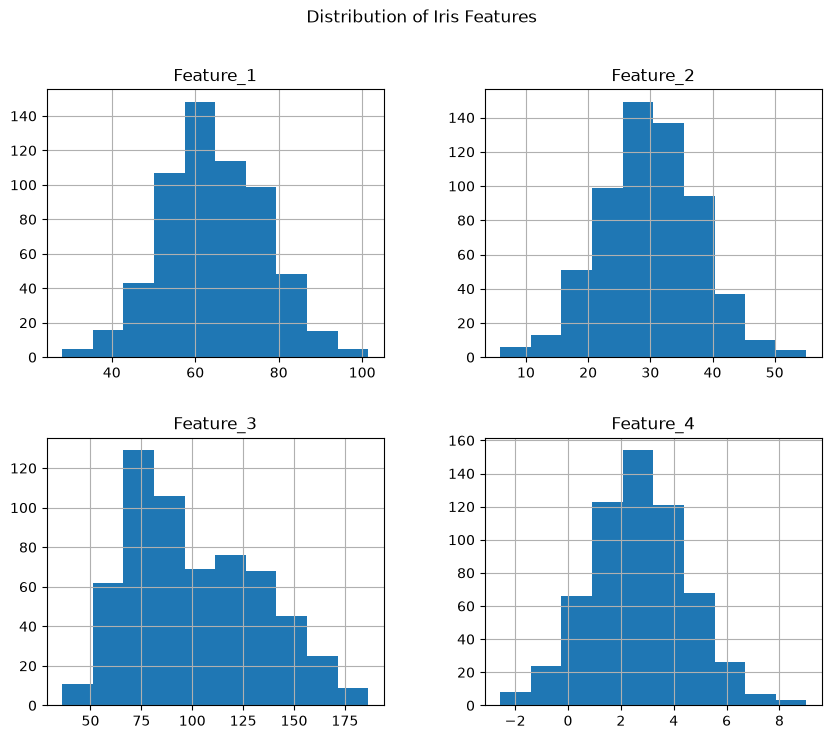

In [38]:
df.hist(figsize=(10,8))
plt.suptitle("Distribution of Iris Features")
plt.show()

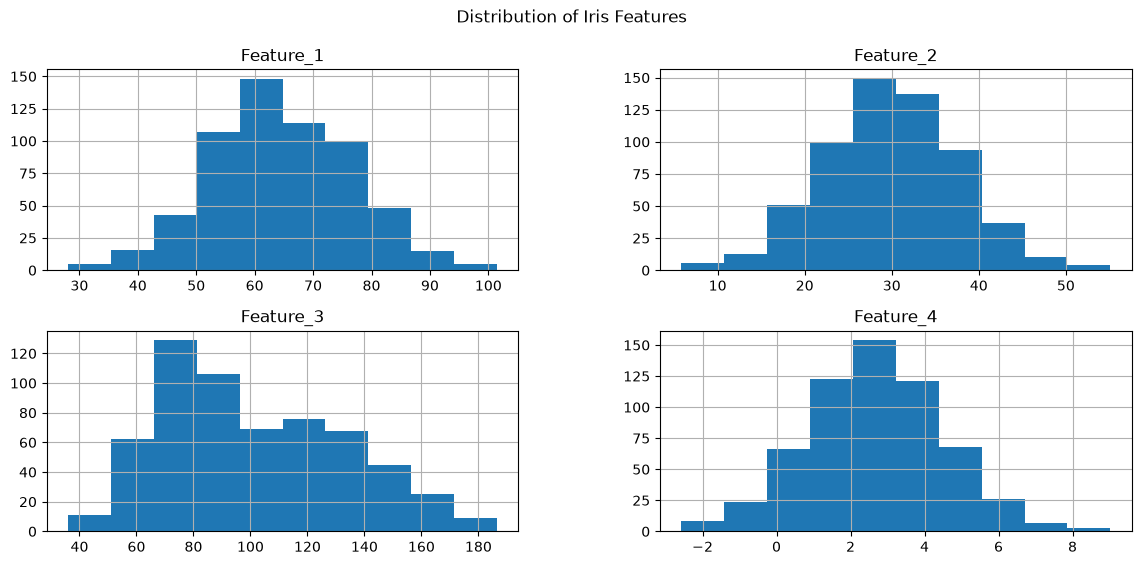

In [39]:
df.hist(figsize=(14, 6))
plt.suptitle("Distribution of Iris Features")
plt.show()

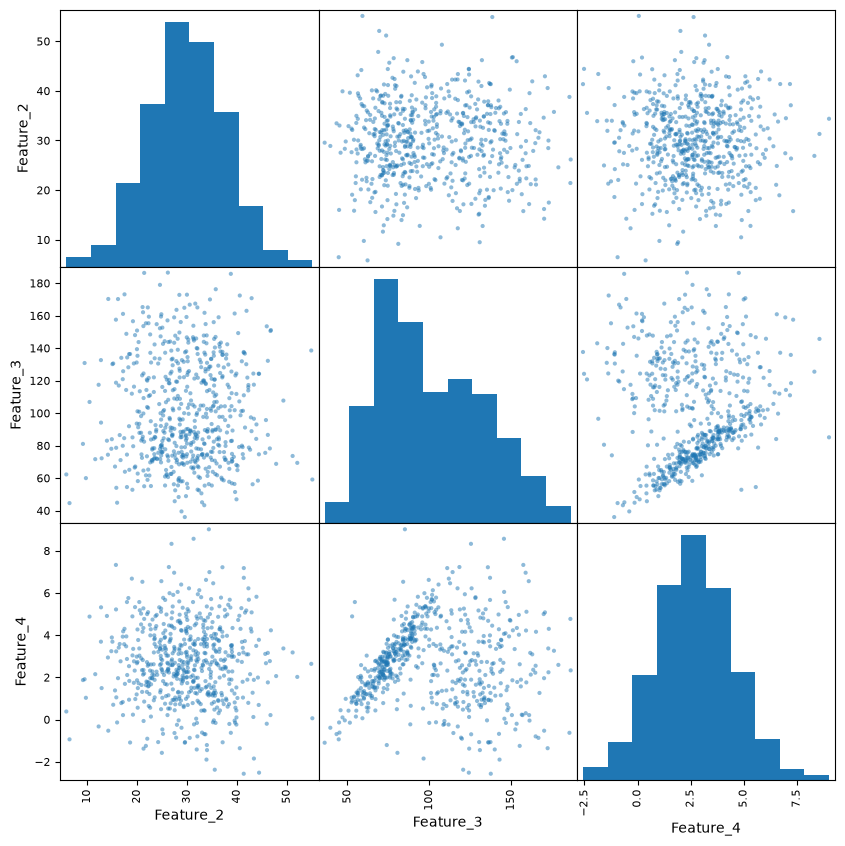

In [40]:
pd.plotting.scatter_matrix(
    df.drop(columns="Feature_1"),
    figsize=(10, 10),
    diagonal="hist"
)
plt.show()

In [49]:
X = df.drop(columns="Target")
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Samples train:", X_train)
print("Samples test:", X_test)

Samples train:      Feature_1  Feature_2  Feature_3  Feature_4
145     100.26      25.93      61.74       3.03
9        47.11      29.93      84.43       3.21
375      62.69      30.27     143.42       2.26
523      36.03      39.38      73.09       2.98
188      63.75      18.40     136.36       0.94
..         ...        ...        ...        ...
71       57.02      34.81      76.26       2.26
106      34.30      32.96      74.35       1.44
270      37.09      36.46      79.98       3.21
435      72.66      22.29     155.35       2.62
102      64.92      43.39     117.52       1.88

[480 rows x 4 columns]
Samples test:      Feature_1  Feature_2  Feature_3  Feature_4
110      59.46      15.79     118.74       5.22
419      85.05      30.01      56.53       2.01
565      64.83      34.49     114.29       6.99
77       69.09      34.68     128.73       2.60
181      76.83      29.99     172.93       2.24
..         ...        ...        ...        ...
399      57.01      39.63      51.4

In [50]:
decision_tree = DecisionTreeClassifier(max_depth=3, random_state=42)

decision_tree.fit(X_train, y_train) 

dt_predictions = decision_tree.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)

print("Decision tree accuracy:", dt_accuracy)

Decision tree accuracy: 0.8583333333333333


In [26]:
print("Missing values")
print("Duplicate rows:", df.duplicated().sum())
display(df.isna().sum().to_frame("Missing"))
print("n/Class Distribution")
display(df["Feature_1"].value_counts())

Missing values
Duplicate rows: 0


,Missing
Feature_1,0
Feature_2,0
Feature_3,0
Feature_4,0
Target,0


n/Class Distribution


Feature_1
75.31    3
75.16    3
76.43    2
61.95    2
52.54    2
        ..
57.59    1
48.21    1
49.66    1
53.27    1
88.12    1
Name: count, Length: 561, dtype: int64